# EEG Signals From Normal and MCI ( Mild Cognitive Impairment ) Cases

EEG Signals From Normal and MCI ( Mild Cognitive Impairment ) Cases: This dataset is a collection of scalp EEG from 27 subjects ( 16 normal and 11 MCI ) aged 60 to 77 with elementary or higher education and history of coronary angiography during recent year. They were selected from patients who admitted to cardiac catheterization units of Sina and Nour Hospitals, Isfahan, Iran. The study design was ethically discussed and approved by the deputy of research and technology, Isfahan University of Medical Sciences, Isfahan, Iran. Subjects with a history of major psychiatric disorders, substance misuse, head trauma, serious medical disease, and dementia were excluded.

The study process was explained for all subjects and written informed consent was obtained. Neuropsychiatric interview considering Peterson`s criteria for Mild Cognitive Impairment ( MCI ) has been done for all subjects. Mini-mental state examination ( MMSE ) scores from 21 to 26 were utilized for validation of MCI diagnosis and scores more than 26, were considered normal controls. Neuropsychiatry unit cognitive assessment tool ( NUCOG ) has been used to confirm the diagnosis of MCI and as a dependent variable.

All EEG signals were recorded in the morning times while subjects resting comfortably in a quiet room with closed eyes. The EEG activity was recorded continuously from 19 electrodes positioned according to the 10–20 International system using 32 channel digital EEG device with 256Hz sampling rate (Galileo NT, EBneuro, Italy). Electrodes-skin impedance was set below 5 kΩ. The recording duration was 30 minutes and during recording procedure subjects were been checked out continuously to keep them conscious and avoid drowsiness. All EEG signals were converted and saved in The European Data Format ( EDF ).

Please reference the following paper if you would like to use any part of this dataset :

M. Kashefpoor, H. Rabbani, and M. Barekatain, "Automatic Diagnosis of Mild Cognitive Impairment Using Electroencephalogram Spectral Features," J Med Signals Sens, vol. 6, pp. 25-32, Jan-Mar 2016

In [2]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import mne # for read .edf file

Test

In [3]:
PATH = r"EEg_Data"
PATH_TEST = os.path.join(PATH, "1.edf")
df_1 = mne.io.read_raw_edf(PATH_TEST, preload=True)
print(df_1.info)

# Data channels
print("Channels:", df_1.ch_names)

# Full data
data = df_1.get_data()
print("Data shape:", data.shape)   # (n_channels, n_samples)

# Time
times = df_1.times
print("Time samples:", len(times))

# If has annotation 
print(df_1.annotations)

# Sample 0 to 10
print(data[0, :10])

Extracting EDF parameters from EEg_Data\1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 465663  =      0.000 ...  1818.996 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F7, F3, Fz, F4, F8, T3, C3, Cz, C4, T4, T5, P3, Pz, ...
 chs: 19 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2080-01-01 00:00:00 UTC
 nchan: 19
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: >
>
Channels: ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']
Data shape: (19, 465664)
Time samples: 465664
<Annotations | 0 segments>
[-8.5928893  -9.3494316  -8.35774777 -3.23575189 -4.86129549 -8.22484169
 -6.47661555 -7.85679408 -7.35584039 -2.48943313]


## Data recognition

In [14]:
# folder of file
PATH = r"EEg_Data"
list_of_file = os.listdir(PATH)
list_of_edf_file = [f for f in os.listdir(PATH) if f.endswith(".edf")]


In [15]:
file_name = "3"

file_name = file_name + ".edf"
for i in range(len(list_of_edf_file)):
    print(i)
    if list_of_edf_file[i] == file_name:
        inx_name = i
        break

PATH_FILE = os.path.join(PATH, file_name)
print(PATH_FILE)
df = mne.io.read_raw_edf(PATH_FILE, preload=True)
df

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
EEg_Data\3.edf
Extracting EDF parameters from EEg_Data\3.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 489471  =      0.000 ...  1911.996 secs...


<RawEDF | 3.edf, 19 x 489472 (1912.0 s), ~71.0 MiB, data loaded>

In [16]:
print("----------------")
print(df.info)
print("----------------")
print(f"Channels: {df.ch_names}")
print("----------------")
print(f"Duration: {df.times[-1]} seconds")

----------------
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F7, F3, Fz, F4, F8, T3, C3, Cz, C4, T4, T5, P3, Pz, ...
 chs: 19 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2080-01-01 00:00:00 UTC
 nchan: 19
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: >
>
----------------
Channels: ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']
----------------
Duration: 1911.99609375 seconds


<Figure size 1200x500 with 0 Axes>

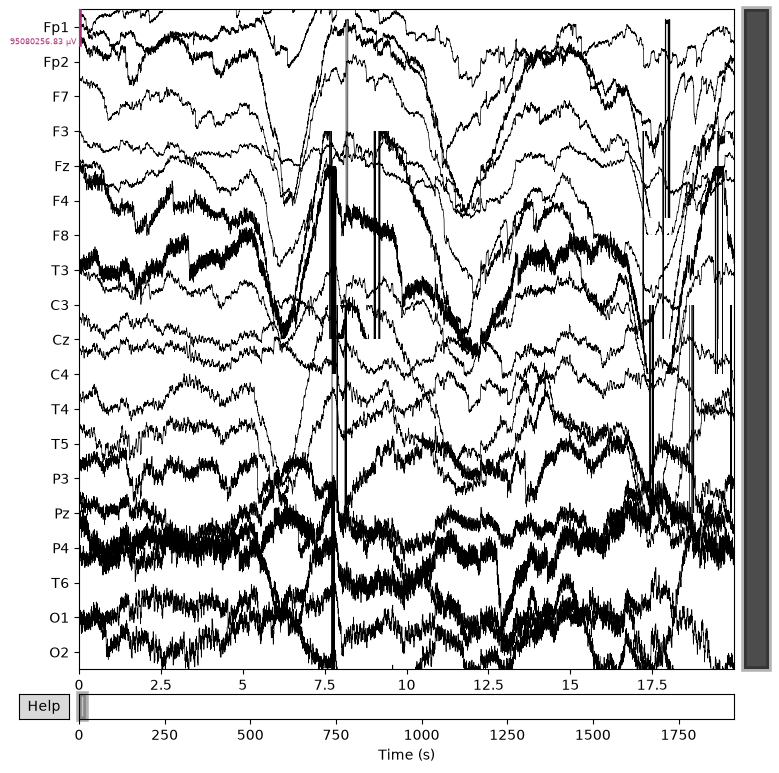

In [17]:
plt.figure(figsize=(12,5))
df.plot(duration=20, n_channels=19, scalings='auto', block=True)
plt.show()

One Channel `Fq1`

Signal shape: (489472,)
Sampling Rate (Sf): 256.0 Hz
First 10 samples: [90.01319905 89.01129168 88.88860914 86.13847562 79.64652476 79.01266499
 73.76798657 72.02998398 70.03639277 69.29007401]


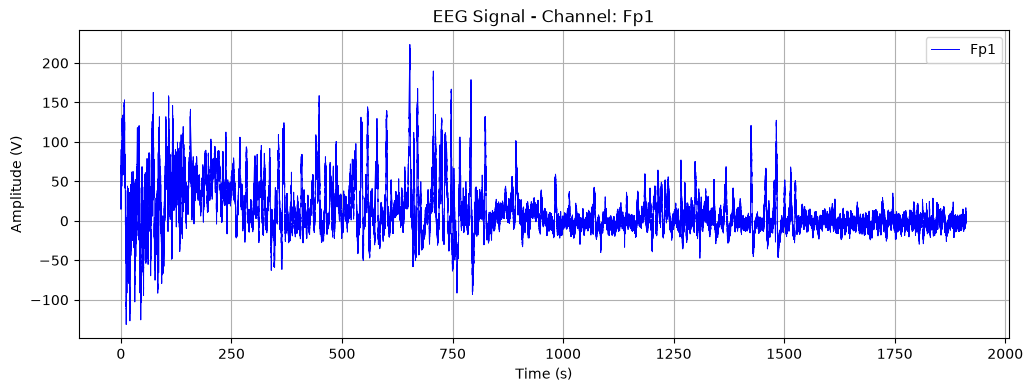

In [18]:
target_channel = 'Fp1'

# Data of channel
raw_channel = df.copy().pick([target_channel])
data, times = raw_channel.get_data(return_times=True)

signal = data[0]
print(f"Signal shape: {signal.shape}")
print(f"Sampling Rate (Sf): {df.info['sfreq']} Hz")
print(f"First 10 samples: {signal[:10]}")

plt.figure(figsize=(12, 4))
plt.plot(times, signal, label=target_channel, color='blue', lw=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')
plt.title(f'EEG Signal - Channel: {target_channel}')
plt.grid(True)
plt.legend()
plt.show()

1) Review the range and convert to microvolts.

In [19]:
signal_uv = signal.copy()

print("Min (µV):", signal_uv.min())
print("Max (µV):", signal_uv.max())
print("Mean (µV):", signal_uv.mean())
print("Std (µV):", signal_uv.std())

Min (µV): -131.30609597924771
Max (µV): 223.46112764171818
Mean (µV): 12.20018358560599
Std (µV): 30.85772741257692


2. Select signal

Plotting the entire 30-minute signal does not show the details. For example, plot a 10-second interval from 100 to 110 seconds:


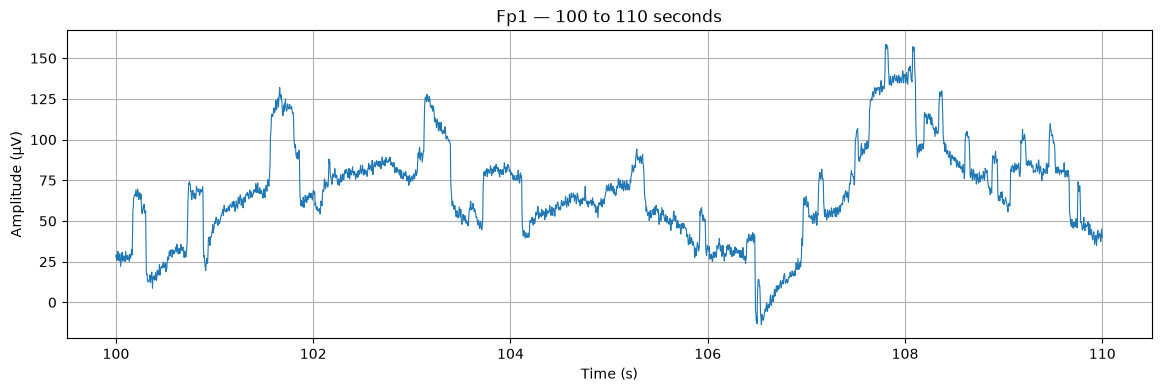

In [20]:
start_sec = 100
end_sec = 110

mask = (times >= start_sec) & (times <= end_sec)

plt.figure(figsize=(14, 4))
plt.plot(times[mask], signal_uv[mask], lw=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title(f"{target_channel} — {start_sec} to {end_sec} seconds")
plt.grid(True)
plt.show()


3) Initial Signal Filtering
For standard EEG, a band-pass filter from 0.5 to 45 Hz is an appropriate starting point.

Apply the filter to the `Raw` object, not directly on the `signal` array.


In [21]:
raw_filtered = df.copy()

raw_filtered.filter(
    l_freq=0.5,
    h_freq=45,
    picks=[target_channel],
    method="fir"
)

raw_filtered.notch_filter(
    freqs=50,
    picks=[target_channel]
)

filtered_signal, times = raw_filtered.copy().pick([target_channel]).get_data(
    return_times=True
)

filtered_signal = filtered_signal[0]
filtered_signal_uv = filtered_signal


Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower pas

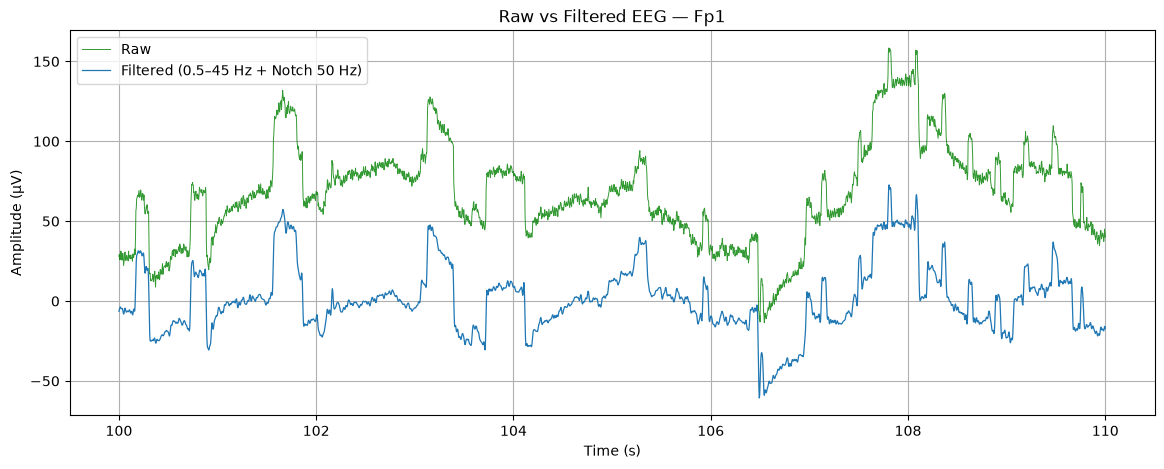

In [22]:
start_sec = 100
end_sec = 110
mask = (times >= start_sec) & (times <= end_sec)

plt.figure(figsize=(14, 5))

plt.plot(
    times[mask],
    signal_uv[mask],
    label="Raw",
    alpha=0.80,
    lw=0.7,
    color="g"
)

plt.plot(
    times[mask],
    filtered_signal_uv[mask],
    label="Filtered (0.5–45 Hz + Notch 50 Hz)",
    lw=0.9
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title(f"Raw vs Filtered EEG — {target_channel}")
plt.grid(True)
plt.legend()
plt.show()


4) Frequency Analysis Using Welch's Method


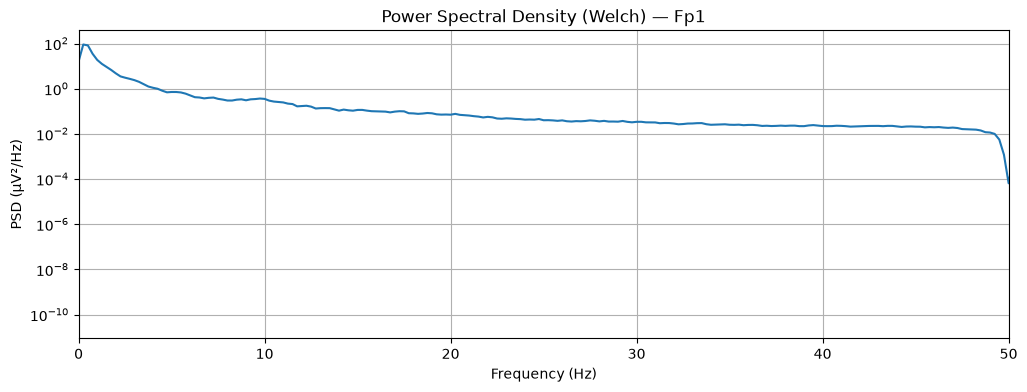

In [23]:
from scipy.signal import welch

sfreq = raw_filtered.info["sfreq"]

frequencies, psd = welch(
    filtered_signal_uv,
    fs=sfreq,
    nperseg=int(sfreq * 4)  # window 4 second
)

plt.figure(figsize=(12, 4))
plt.semilogy(frequencies, psd)
plt.xlim(0, 50)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (µV²/Hz)")
plt.title(f"Power Spectral Density (Welch) — {target_channel}")
plt.grid(True)
plt.show()


4) Calculation of EEG Frequency Band Power


In [24]:
bands = {
    "Delta (0.5–4 Hz)": (0.5, 4),
    "Theta (4–8 Hz)": (4, 8),
    "Alpha (8–13 Hz)": (8, 13),
    "Beta (13–30 Hz)": (13, 30),
    "Gamma (30–45 Hz)": (30, 45),
}

band_powers = {}

for band_name, (low_freq, high_freq) in bands.items():
    idx = (frequencies >= low_freq) & (frequencies < high_freq)

    power = np.trapezoid(psd[idx], frequencies[idx])
    band_powers[band_name] = power

band_power_df = pd.DataFrame(
    band_powers.items(),
    columns=["Band", "Power (µV²)"]
)

band_power_df["Relative Power (%)"] = (
    100 * band_power_df["Power (µV²)"] / band_power_df["Power (µV²)"].sum()
)

display(band_power_df)


,Band,Power (µV²),Relative Power (%)
0,Delta (0.5–4 Hz),36.079800,87.918731
1,Theta (4–8 Hz),2.193380,5.344796
2,Alpha (8–13 Hz),1.264672,3.081734
3,Beta (13–30 Hz),1.133161,2.761270
4,Gamma (30–45 Hz),0.366659,0.893469
